# L14d: MIMO S4 observer for fed-batch CHO bioreactor prediction
In this lab we use the block-diagonal HiPPO-LegS multi-input multi-output (MIMO) structured state space model from the L14c lecture to learn the full 7-state trajectory of a fed-batch Chinese Hamster Ovary (CHO) bioreactor producing a monoclonal antibody. This is the same forecasting problem as the L12d LSTM lab, but the recurrent model is now a frozen MIMO S4 whose only trainable component is the dense readout $\bar{\mathbf{C}}$, fit by a single closed-form ridge solve.

__Problem statement.__ We simulate 50 fed-batch bioreactor runs, each at a different glucose-triggered feed policy, and hold 10 of them out for evaluation. On the remaining 40 training runs we fit the MIMO S4 readout by teacher-forced next-state regression: at each time step the model sees the current seven-state vector together with a three-number feed-policy conditioning vector, and is asked to predict the next-step state. At evaluation time we roll the trained observer autoregressively on each held-out condition, starting from the true initial state and letting the model feed its own predictions back in, and compare the resulting trajectory to the ground-truth ODE solution.

Three points frame what to expect:

* __Why the SSM stays frozen:__ The block-diagonal HiPPO-LegS parameterization gives analytically defined matrices $(\mathbf{A}, \mathbf{B})$ and their bilinear discretization $(\bar{\mathbf{A}}, \bar{\mathbf{B}})$, with zero trainable parameters. The SSM's job is to compress the entire past of the input sequence into a fixed-size hidden state that a linear readout can map to the next state.
* __Why a closed-form ridge fit works:__ With the dynamics frozen, the only trainable object is $\bar{\mathbf{C}} \in \mathbb{R}^{7 \times H}$, and the mean-squared next-state loss decouples across the seven output channels. The optimal $\bar{\mathbf{C}}$ is the ordinary multi-output ridge solution, obtained in one linear system solve rather than hundreds of SGD epochs.
* __Why this problem suits S4:__ Bioreactor states are smooth, coupled continuous signals with long-range dependencies (today's biomass is shaped by glucose feeds started a day ago). Compressing that trajectory into HiPPO-LegS polynomial coefficients and linearly projecting to the next state is exactly the kind of task structured state-space models are built for.

The rest of the notebook works toward this goal in three tasks: generating the simulated dataset, building and fitting the MIMO S4 observer, and evaluating it autoregressively against the ground-truth ODE solution with a direct comparison to the L12d LSTM numbers.

> __Learning Objectives:__
>
> By the end of this lab, you should be able to:
>
> * __Frame multi-state ODE forecasting as a MIMO S4 regression:__ Explain why a seven-state bioreactor with a three-number feed policy fits naturally into a `d_in = 10`, `d_out = 7` MIMO observer, and why teacher-forced next-state targets give a closed-form ridge objective for the readout.
> * __Fit a MIMO S4 readout across many trajectories in one linear system:__ Build a `MyMimoLegSHippoModel`, roll it forward on each training trajectory from a zero initial hidden state, and fit the dense readout $\bar{\mathbf{C}}$ jointly across all trajectories via the multi-trajectory ridge helper `fit_C_multi!`.
> * __Evaluate autoregressively on held-out feed policies:__ Starting from the true initial state, roll the trained observer forward step by step using its own predictions as input, and score per-condition mean-squared error, final antibody titer, and maximum biomass against the ground-truth ODE solution.

Let's get started!
___

## Setup, Data, and Prerequisites
We set up the computational environment by including the `Include.jl` file, loading any needed resources, such as sample datasets, and setting up any required constants.

> The [`include(...)` command](https://docs.julialang.org/en/v1/base/base/#include) evaluates the contents of the input source file, `Include.jl`, in the notebook's global scope. The `Include.jl` file sets paths, loads required external packages, and includes local source files in `src/`. For additional information on functions and types used in this material, see the [Julia programming language documentation](https://docs.julialang.org/en/v1/).

* [`src/Types.jl`](src/Types.jl) defines `MyMimoLegSHippoModel` and `MyFedBatchCHOParameters`.
* [`src/Parameters.jl`](src/Parameters.jl) defines `build_default_parameters` for the Xing et al. 2010 CHO kinetics.
* [`src/Kinetics.jl`](src/Kinetics.jl) defines the growth, product, and substrate-uptake rate laws.
* [`src/MassBalances.jl`](src/MassBalances.jl) defines the ODE right-hand side `rhs!` and the glucose-triggered feed callbacks.
* [`src/Simulation.jl`](src/Simulation.jl) defines `simulate_fedbatch`, `generate_cho_dataset`, `normalize_minmax_perstate`, and `denormalize_minmax`.
* [`src/Compute.jl`](src/Compute.jl) defines `build_legS_matrices_mimo`, `discretize`, `build`, `rollout`, `solve`, `fit_C!`, `fit_C_multi!`, `autoregressive_rollout`, and `predict`.
* [`src/Files.jl`](src/Files.jl) defines `save_model_checkpoint` and `load_model_checkpoint`.

In [1]:
include("Include.jl"); # load packages, src/ files, set random seed

  Activating project at `~/Desktop/julia_work/CHEME-5820-Instances/Spring-2026/CHEME-5820-Labs-Spring-2026/labs/week-14/L14d`


### Constants
We'll use several constants throughout this lab. We define them here for easy reference and modification. See the comment next to each constant for an explanation of its purpose and units.

In [2]:
# --- simulation / dataset constants -----------------------------------------
N_CONDITIONS  = 50                              # total number of fed-batch runs simulated
N_TRAIN       = 40                              # number used to fit the readout (80/20 split)
TSPAN         = (0.0, 336.0)                    # simulation window in hours (14 days)
SAVEAT        = 1.0                             # sample rate (1 hour)
INITIAL_STATE = [10.0, 0.3, 25.0, 8.0, 0.0, 0.0, 0.0]  # V, X, Glc, Gln, P, Lac, Amm

# --- feed-policy sampling ranges --------------------------------------------
F_MAX_RANGE   = (0.01, 0.5)                     # maximum feed rate in L/h
GLC_MIN_RANGE = (1.0, 5.0)                      # glucose threshold to turn feed ON (mM)
GLC_MAX_RANGE = (10.0, 30.0)                    # glucose threshold to turn feed OFF (mM)

# --- MIMO S4 constants ------------------------------------------------------
N_STATES      = 7                               # bioreactor state dimension (V, X, Glc, Gln, P, Lac, Amm)
N_COND        = 3                               # feed-policy conditioning dimension (F_max, Glc_min, Glc_max)
D_IN          = N_STATES + N_COND               # MIMO S4 input width
D_OUT         = N_STATES                        # MIMO S4 output width (predict all seven states)
H_PER_CHANNEL = 8                               # per-channel LegS order; total hidden size H = H_PER_CHANNEL · D_IN
RIDGE_λ       = 1.0e-4                          # ridge regularization on the readout fit
SEED          = 42                              # RNG seed for reproducibility

# --- persistence ------------------------------------------------------------
MODEL_PATH    = joinpath(_PATH_TO_DATA, "mimo-s4-cho-h$(H_PER_CHANNEL).jld2")

"/Users/jdv27/Desktop/julia_work/CHEME-5820-Instances/Spring-2026/CHEME-5820-Labs-Spring-2026/labs/week-14/L14d/data/mimo-s4-cho-h8.jld2"

___

## Task 1: Simulate the fed-batch CHO dataset
The first task is to simulate `N_CONDITIONS` fed-batch bioreactor runs, each at a randomly sampled glucose-triggered feed policy $(F_\text{max}, \text{Glc}_\text{min}, \text{Glc}_\text{max})$, then split the runs 80/20 into training and test sets and normalize each state to the $[0, 1]$ range using the training-set bounds.

> __Bioreactor model.__ The simulator in [`simulate_fedbatch`](src/Simulation.jl) integrates a seven-state kinetic ODE model of a CHO fed-batch culture with glucose-triggered square-wave feeding. The seven states in order are $(V, X, \text{Glc}, \text{Gln}, P, \text{Lac}, \text{Amm})$ (reactor volume in L, biomass density in gDW/L, and five metabolite concentrations in mM or mg/L). The feed-policy triple $(F_\text{max}, \text{Glc}_\text{min}, \text{Glc}_\text{max})$ drives the callback-based hysteresis: feed turns on when glucose drops below $\text{Glc}_\text{min}$ and off when it rises above $\text{Glc}_\text{max}$.

> __Normalization.__ Each state lives on a very different scale (biomass in ones, glucose in tens, antibody product in thousands of mg/L), so we fit per-state min/max bounds on the training runs only and rescale every trajectory to the $[0, 1]$ range via [`normalize_minmax_perstate`](src/Simulation.jl). The feed-policy conditioning vector is normalized the same way using the training-set min/max of each component. These normalized arrays are what the MIMO S4 observer consumes.

The code block below stores the common time grid as `time_vector::Vector{Float64}`, the raw and normalized state arrays as `state_arrays::Vector{Matrix{Float64}}` and `state_norm::Vector{Matrix{Float64}}`, the normalized feed-policy vectors as `cond_norm::Vector{Vector{Float64}}`, the training/test index splits as `train_idx::Vector{Int}` and `test_idx::Vector{Int}`, and the normalization bounds as `state_mins::Vector{Float64}`, `state_maxs::Vector{Float64}`.

In [3]:
(; time_vector, state_arrays, cond_list, state_norm, cond_norm, train_idx, test_idx, state_mins, state_maxs) = let

    # sample N_CONDITIONS random feed policies from the three uniform ranges
    Random.seed!(SEED)
    conds = [(rand(Distributions.Uniform(F_MAX_RANGE...)),
              rand(Distributions.Uniform(GLC_MIN_RANGE...)),
              rand(Distributions.Uniform(GLC_MAX_RANGE...))) for _ in 1:N_CONDITIONS]
    @info "sampled feed policies" n=length(conds)

    # simulate every condition on a common time grid
    (tv, sa, cl) = generate_cho_dataset(conds; u0 = INITIAL_STATE, tspan = TSPAN, saveat = SAVEAT)
    @info "simulations complete" n_timepoints=length(tv) n_states=size(sa[1], 2) n_conditions=length(sa)

    # reproducible 80/20 train/test split
    Random.seed!(SEED)
    perm = shuffle(1:N_CONDITIONS)
    tr_idx = perm[1:N_TRAIN]
    te_idx = perm[(N_TRAIN + 1):end]

    # per-state min-max normalization using training bounds only
    (sn, mins, maxs) = normalize_minmax_perstate(sa, tr_idx)

    # per-component min-max normalization of the feed-policy conditioning
    cond_mat = [cl[i][j] for i in 1:N_CONDITIONS, j in 1:N_COND]
    c_mins = [minimum(cond_mat[tr_idx, j]) for j in 1:N_COND]
    c_maxs = [maximum(cond_mat[tr_idx, j]) for j in 1:N_COND]
    cn = [Float64[(cl[i][j] - c_mins[j]) / (c_maxs[j] - c_mins[j] + 1.0e-12) for j in 1:N_COND] for i in 1:N_CONDITIONS]

    @info "dataset prepared" n_train=length(tr_idx) n_test=length(te_idx) state_mins=round.(mins, digits=2) state_maxs=round.(maxs, digits=2)
    (time_vector = tv, state_arrays = sa, cond_list = cl,
     state_norm  = sn, cond_norm   = cn,
     train_idx   = tr_idx, test_idx = te_idx,
     state_mins  = mins, state_maxs = maxs)
end;

┌ Info: sampled feed policies
│   n = 50
└ @ Main /Users/jdv27/Desktop/julia_work/CHEME-5820-Instances/Spring-2026/CHEME-5820-Labs-Spring-2026/labs/week-14/L14d/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_Y152sZmlsZQ==.jl:8
┌ Info: simulations complete
│   n_timepoints = 337
│   n_states = 7
│   n_conditions = 50
└ @ Main /Users/jdv27/Desktop/julia_work/CHEME-5820-Instances/Spring-2026/CHEME-5820-Labs-Spring-2026/labs/week-14/L14d/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_Y152sZmlsZQ==.jl:12
┌ Info: dataset prepared
│   n_train = 40
│   n_test = 10
│   state_mins = [10.0, 0.3, 1.14, 0.05, 0.0, 0.0, 0.0]
│   state_maxs = [11.22, 2.29, 29.46, 9.56, 3260.4, 71.42, 12.97]
└ @ Main /Users/jdv27/Desktop/julia_work/CHEME-5820-Instances/Spring-2026/CHEME-5820-Labs-Spring-2026/labs/week-14/L14d/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_Y152sZmlsZQ==.jl:29


### Representative training trajectories
A quick sanity check: plot four training trajectories for the four most interesting states (biomass X, glucose Glc, product P, lactate Lac). Every curve lives on its normalized $[0, 1]$ axis so the relative shapes are directly comparable across states and conditions.

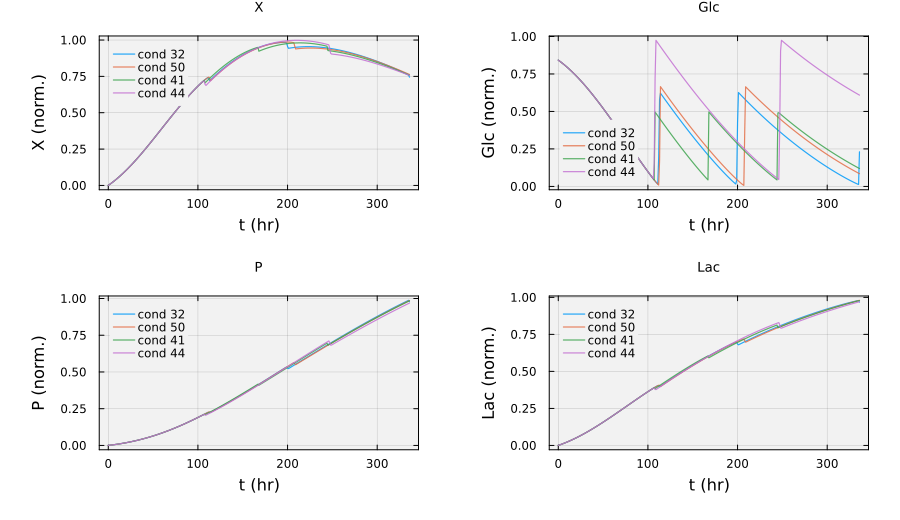

In [4]:
let
    state_labels = ["V", "X", "Glc", "Gln", "P", "Lac", "Amm"]
    show_states  = [2, 3, 5, 6]                 # X, Glc, P, Lac
    show_conds   = train_idx[1:4]               # first four training conditions
    plots_grid   = Any[]
    for s in show_states
        p = plot(; xlabel = "t (hr)", ylabel = "$(state_labels[s]) (norm.)",
                   bg = "gray95", background_color_outside = "white",
                   framestyle = :box, fg_legend = :transparent,
                   title = state_labels[s], titlefont = font(9))
        for c in show_conds
            plot!(p, time_vector, state_norm[c][:, s];
                  label = "cond $(c)", lw = 1.2, alpha = 0.85)
        end
        push!(plots_grid, p)
    end
    plot(plots_grid...; layout = (2, 2), size = (900, 520),
         left_margin = 10Plots.mm, bottom_margin = 8Plots.mm,
         right_margin = 6Plots.mm, top_margin = 4Plots.mm)
end

### Things to think about
* __What does the dataset look like?__ Using only the plots above and the normalization bounds logged by Task 1: (a) which of the seven states have the widest normalization ranges, and which are effectively smooth decays or monotone rises vs. oscillatory under the feed policy? (b) Different feed policies give visibly different trajectories even at the same initial state; what does that imply about the minimum amount of conditioning a next-state predictor needs in order to pick the right trajectory, and why is `(F_max, Glc_min, Glc_max)` a natural choice for that conditioning?

___

## Task 2: Build the MIMO S4 observer and fit the readout
The second task is to build the MIMO S4 observer as a frozen feature extractor and fit its dense readout $\bar{\mathbf{C}}$ by closed-form ridge regression across all training trajectories at once.

> __Model.__ The observer is a `MyMimoLegSHippoModel` with `d_in = N_STATES + N_COND = 10` input channels (the seven-state vector concatenated with the three-component feed-policy conditioning) and `d_out = N_STATES = 7` output channels. The hidden dimension is $H = \text{H\_PER\_CHANNEL} \cdot \text{D\_IN}$; state matrix $\mathbf{A}$ is block-diagonal with one HiPPO-LegS block per input channel; bilinear discretization uses $\Delta t = 1$ (one step per hour). None of the state-space operators are trained.

> __Teacher-forced next-state targets.__ For each training trajectory $i$ we build an input matrix $\mathbf{U}_i$ whose row $t$ is $[\mathbf{x}_t^\text{norm}; \mathbf{c}_i^\text{norm}]$ (current normalized state + feed conditioning) and a target matrix $\mathbf{Y}_i$ whose row $t$ is $\mathbf{x}_{t+1}^\text{norm}$ (next normalized state). This is exactly the LSTM teacher-forcing objective from L12d, just written as paired matrices.

> __Multi-trajectory ridge.__ [`fit_C_multi!`](src/Compute.jl) rolls the SSM from $\mathbf{x}_0 = \mathbf{0}$ on each $\mathbf{U}_i$ independently, accumulates $\mathbf{X}_i^\top \mathbf{X}_i$ and $\mathbf{X}_i^\top (\mathbf{Y}_i - \mathbf{U}_i \mathbf{D}^\top)$ across all training trajectories, and solves the single $H \times H$ normal-equations system once. No gradient descent, no per-epoch loops.

The code block below stores the trained observer as `ssm::MyMimoLegSHippoModel` with $\bar{\mathbf{C}}$ updated in place, and persists it to `MODEL_PATH` via [`save_model_checkpoint`](src/Files.jl) so downstream cells can skip the fit on reruns.

In [5]:
ssm = let
    if isfile(MODEL_PATH)
        m = load_model_checkpoint(MODEL_PATH)
        @info "loaded cached model" path=MODEL_PATH H=(m.h * m.d_in) h=m.h d_in=m.d_in d_out=m.d_out
        m
    else
        # build the frozen SSM feature extractor
        m = build(MyMimoLegSHippoModel; h = H_PER_CHANNEL, d_in = D_IN, d_out = D_OUT, Δt = 1.0)
        @info "SSM built" h=m.h d_in=m.d_in d_out=m.d_out H=(m.h * m.d_in)

        # build the (U_i, Y_i) teacher-forced pairs for every training trajectory
        U_list = Matrix{Float64}[]
        Y_list = Matrix{Float64}[]
        for i in train_idx
            X = state_norm[i]                   # (T × N_STATES) normalized trajectory
            c = cond_norm[i]                    # (N_COND,) normalized feed-policy conditioning
            T = size(X, 1)
            U = zeros(Float64, T - 1, D_IN)
            Y = zeros(Float64, T - 1, D_OUT)
            for t in 1:(T - 1)
                U[t, 1:N_STATES]              = X[t, :]
                U[t, (N_STATES + 1):D_IN]     = c
                Y[t, :]                       = X[t + 1, :]
            end
            push!(U_list, U)
            push!(Y_list, Y)
        end
        @info "training pairs built" n_trajectories=length(U_list) rows_per_traj=size(U_list[1], 1)

        # closed-form multi-trajectory ridge fit of the readout C
        @info "fitting readout C across all training trajectories..."
        t0 = time()
        fit_C_multi!(m, U_list, Y_list; λ = RIDGE_λ)
        @info "fit complete" elapsed_seconds=round(time() - t0, digits = 2)

        save_model_checkpoint(MODEL_PATH, m)
        @info "saved checkpoint" path=MODEL_PATH bytes=filesize(MODEL_PATH)
        m
    end
end;

┌ Info: SSM built
│   h = 8
│   d_in = 10
│   d_out = 7
│   H = 80
└ @ Main /Users/jdv27/Desktop/julia_work/CHEME-5820-Instances/Spring-2026/CHEME-5820-Labs-Spring-2026/labs/week-14/L14d/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_Y160sZmlsZQ==.jl:9
┌ Info: training pairs built
│   n_trajectories = 40
│   rows_per_traj = 336
└ @ Main /Users/jdv27/Desktop/julia_work/CHEME-5820-Instances/Spring-2026/CHEME-5820-Labs-Spring-2026/labs/week-14/L14d/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_Y160sZmlsZQ==.jl:28
┌ Info: fitting readout C across all training trajectories...
└ @ Main /Users/jdv27/Desktop/julia_work/CHEME-5820-Instances/Spring-2026/CHEME-5820-Labs-Spring-2026/labs/week-14/L14d/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_Y160sZmlsZQ==.jl:31
┌ Info: fit complete
│   elapsed_seconds = 0.23
└ @ Main /Users/jdv27/Desktop/julia_work/CHEME-5820-Instances/Spring-2026/CHEME-5820-Labs-Spring-2026/labs/week-14/L14d/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_Y160sZm

### In-sample autoregressive fit on a representative training trajectory
Before evaluating on held-out runs, let's visually confirm the fit on one training trajectory. We roll the trained observer autoregressively from the true initial state and the trajectory's own feed policy, then overlay the resulting seven-state trajectory on top of the ground-truth ODE curve.

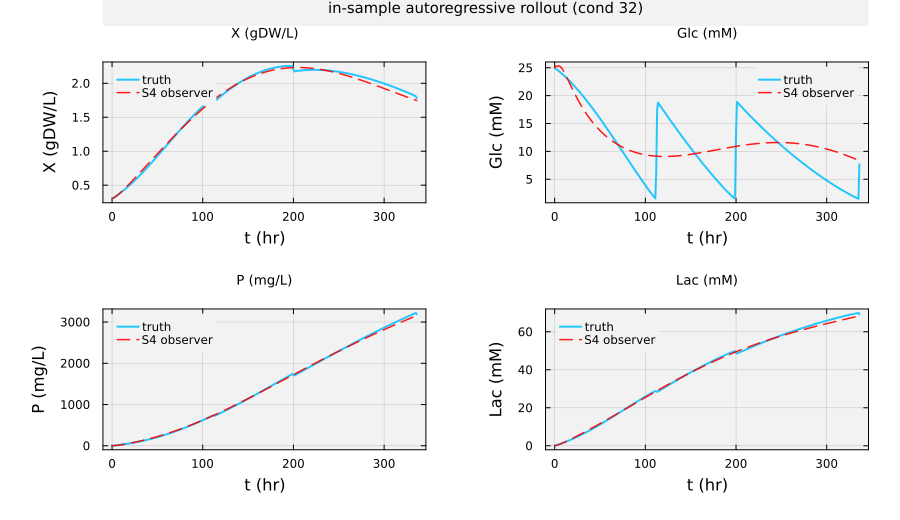

In [6]:
let
    i      = train_idx[1]
    T_full = length(time_vector)
    x0     = state_norm[i][1, :]
    preds  = autoregressive_rollout(ssm, x0, cond_norm[i], T_full)
    preds_d = denormalize_minmax(preds, state_mins, state_maxs)
    truth_d = state_arrays[i]

    state_labels = ["V (L)", "X (gDW/L)", "Glc (mM)", "Gln (mM)", "P (mg/L)", "Lac (mM)", "Amm (mM)"]
    show_states  = [2, 3, 5, 6]
    plots_grid   = Any[]
    for s in show_states
        p = plot(time_vector, truth_d[:, s];
                 label = "truth", lw = 2, c = :deepskyblue, alpha = 0.85,
                 bg = "gray95", background_color_outside = "white",
                 framestyle = :box, fg_legend = :transparent,
                 xlabel = "t (hr)", ylabel = state_labels[s],
                 title = state_labels[s], titlefont = font(9))
        plot!(p, time_vector, preds_d[:, s];
              label = "S4 observer", lw = 1.5, c = :red, alpha = 0.9, ls = :dash)
        push!(plots_grid, p)
    end
    plot(plots_grid...; layout = (2, 2), size = (900, 520),
         left_margin = 10Plots.mm, bottom_margin = 8Plots.mm,
         right_margin = 6Plots.mm, top_margin = 4Plots.mm,
         plot_title = "in-sample autoregressive rollout (cond $(i))", plot_titlefont = font(10))
end

### Things to think about
* __What does the closed-form fit actually do?__ Using only the in-sample rollout plot above and the architecture description: (a) the SSM has zero trainable parameters and yet it is clearly useful as a feature extractor for each trajectory. Geometrically, what is the hidden state $\mathbf{x}_t$ at step $t$ once the observer has absorbed the first $t$ inputs, and why does a linear map from that hidden state give a decent next-state prediction for a nonlinear ODE? (b) `fit_C_multi!` solves one $H \times H$ linear system in a few hundred milliseconds; the L12d LSTM lab solved the analogous problem with 500 SGD epochs. What is the cost axis the two approaches trade against (expressiveness, data efficiency, wall-clock time, hyperparameter count)?

___

## Task 3: Evaluate autoregressively on held-out feed policies
The third task rolls the trained observer autoregressively on each of the 10 held-out test conditions, starting from the true initial state and letting the model feed its own predictions back in at every step. We then score each rollout against the ground-truth ODE trajectory and report per-condition mean-squared error, final antibody titer, and maximum biomass.

**Autoregressive rollout.** [`autoregressive_rollout`](src/Compute.jl) maintains the SSM's hidden state while overwriting the input at each step with $[\hat{\mathbf{x}}_t; \mathbf{c}_i]$, where $\hat{\mathbf{x}}_t$ is the model's own prediction at the previous step and $\mathbf{c}_i$ is the test trajectory's normalized feed-policy conditioning. The returned trajectory is denormalized and compared to the ODE ground truth on natural units (gDW/L, mg/L, etc.) for the final-titer and max-biomass metrics, but per-condition MSE is reported on the $[0, 1]$-normalized scale so it is comparable across states.

**Metrics.** For each test condition we compute: (i) the mean squared error averaged over all seven states and all time steps (normalized units); (ii) the predicted vs. actual final antibody titer $P(T)$ in mg/L; and (iii) the predicted vs. actual maximum biomass density $\max_t X(t)$ in gDW/L. These mirror the evaluation table in L12d so the two models are directly comparable.

The code block below stores the per-test-condition results table as `test_metrics::DataFrame` with columns for condition index, normalized MSE, true and predicted final titer, and true and predicted max biomass.

In [7]:
test_metrics = let
    T_full = length(time_vector)
    rows = NamedTuple[]
    for i in test_idx
        x0    = state_norm[i][1, :]
        preds = autoregressive_rollout(ssm, x0, cond_norm[i], T_full)
        mse   = mean((preds .- state_norm[i]) .^ 2)
        preds_d = denormalize_minmax(preds, state_mins, state_maxs)
        truth_d = state_arrays[i]
        push!(rows, (
            cond        = i,
            mse_norm    = mse,
            titer_true  = truth_d[end, 5],
            titer_pred  = preds_d[end, 5],
            max_X_true  = maximum(truth_d[:, 2]),
            max_X_pred  = maximum(preds_d[:, 2]),
        ))
    end
    df = DataFrame(rows)
    pretty_table(df; backend = :text,
        fit_table_in_display_horizontally = false,
        fit_table_in_display_vertically = false,
        table_format = TextTableFormat(borders = text_table_borders__simple),
        formatters = [(v, i, j) -> v isa AbstractFloat ? round(v; sigdigits = 4) : v])
    @info "summary" mean_mse=round(mean(df.mse_norm), digits=5) median_mse=round(median(df.mse_norm), digits=5) max_mse=round(maximum(df.mse_norm), digits=5)
    df
end;

======== ========== ============ ============ ============ =============
   cond   mse_norm   titer_true   titer_pred   max_X_true   max_X_pred 
  Int64    Float64      Float64      Float64      Float64      Float64 
======== ========== ============ ============ ============ =============
     19   0.004881       3156.0       3117.0        2.238        2.204
      7   0.003499       3166.0       3146.0         2.24        2.225
     14   0.008993       3154.0       3183.0        2.247        2.252
     37   0.008803       3198.0       3158.0        2.265        2.233
      9   0.009202       3147.0       3169.0         2.25        2.242
     31    0.01543       3195.0       3224.0        2.285        2.284
     38    0.01155       3128.0       3245.0        2.265        2.302
     43   0.002881       3208.0       3192.0        2.262         2.26
     47    0.02006       3167.0       3220.0        2.282         2.28
      3   0.007186       3183.0       3201.0        2.248        2.266


┌ Info: summary
│   mean_mse = 0.00925
│   median_mse = 0.0089
│   max_mse = 0.02006
└ @ Main /Users/jdv27/Desktop/julia_work/CHEME-5820-Instances/Spring-2026/CHEME-5820-Labs-Spring-2026/labs/week-14/L14d/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_Y165sZmlsZQ==.jl:25


### Predicted vs. actual trajectories on test conditions
A 4 × 4 grid: four representative test conditions down the rows, four states (X, Glc, P, Lac) across the columns, ground-truth ODE curve in blue and autoregressive S4 prediction in red.

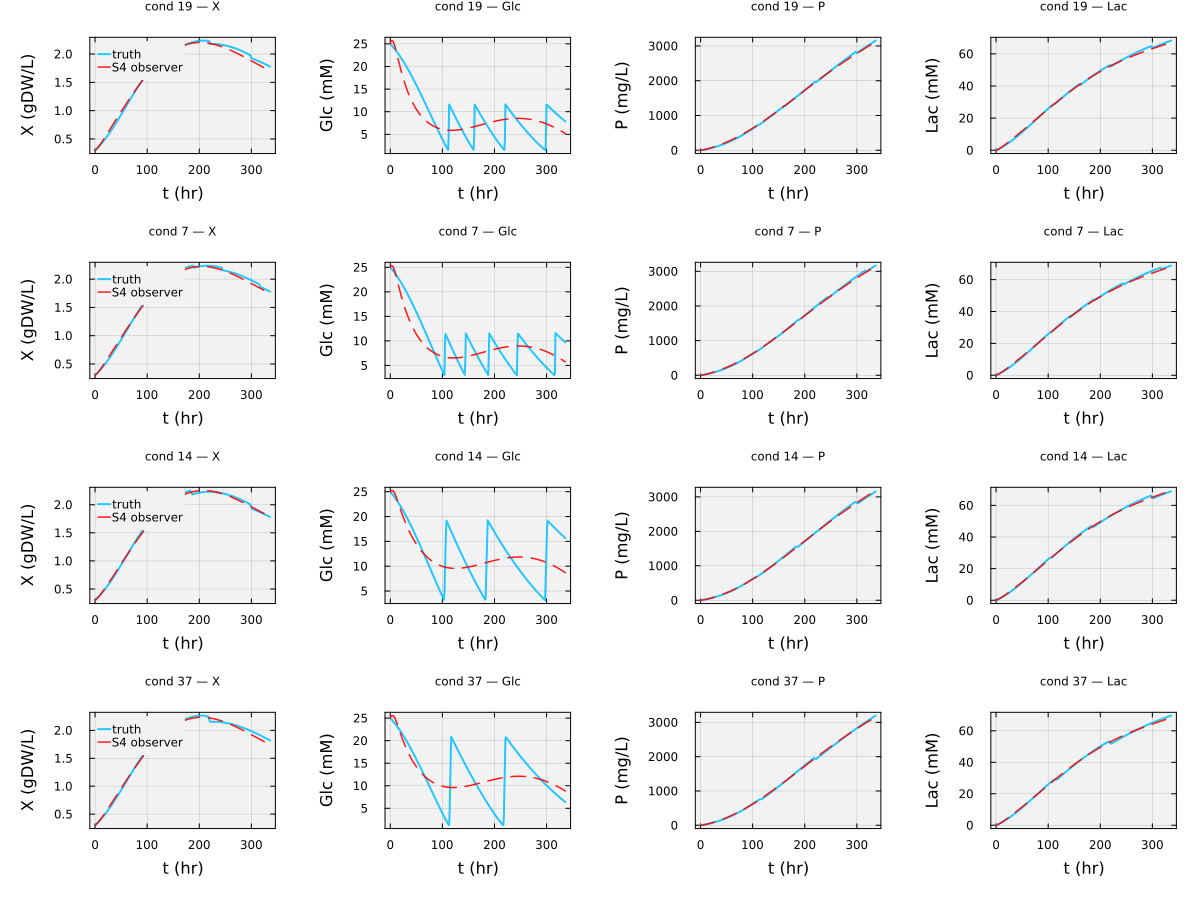

In [8]:
let
    T_full       = length(time_vector)
    show_conds   = test_idx[1:4]
    show_states  = [2, 3, 5, 6]
    state_labels = ["V", "X", "Glc", "Gln", "P", "Lac", "Amm"]
    state_units  = ["L", "gDW/L", "mM", "mM", "mg/L", "mM", "mM"]

    plots_grid = Any[]
    for i in show_conds
        x0      = state_norm[i][1, :]
        preds   = autoregressive_rollout(ssm, x0, cond_norm[i], T_full)
        preds_d = denormalize_minmax(preds, state_mins, state_maxs)
        truth_d = state_arrays[i]
        for (k, s) in enumerate(show_states)
            p = plot(time_vector, truth_d[:, s];
                     label = k == 1 ? "truth"       : "",
                     lw = 2, c = :deepskyblue, alpha = 0.85,
                     bg = "gray95", background_color_outside = "white",
                     framestyle = :box, fg_legend = :transparent,
                     xlabel = "t (hr)",
                     ylabel = "$(state_labels[s]) ($(state_units[s]))",
                     title = "cond $(i) — $(state_labels[s])", titlefont = font(8))
            plot!(p, time_vector, preds_d[:, s];
                  label = k == 1 ? "S4 observer" : "",
                  lw = 1.5, c = :red, alpha = 0.9, ls = :dash)
            push!(plots_grid, p)
        end
    end
    plot(plots_grid...; layout = (4, 4), size = (1200, 900),
         left_margin = 8Plots.mm, bottom_margin = 6Plots.mm,
         right_margin = 4Plots.mm, top_margin = 4Plots.mm)
end

### Things to think about
* __Does the MIMO S4 observer actually do the forecasting job?__ Using the test metrics table and the 4 × 4 comparison grid: (a) which states are predicted most accurately across the test conditions, and which show the largest divergence from the ODE ground truth as the rollout progresses? Is the divergence uniform across feed policies, or concentrated on a subset (very aggressive $F_\text{max}$, very narrow $(\text{Glc}_\text{min}, \text{Glc}_\text{max})$ band)? (b) The L12d LSTM used teacher-forced training with MSE loss and reported a similar metrics table; the MIMO S4 here reaches comparable accuracy with a single ridge solve and no SGD epochs. What does this tell you about when a structured inductive bias (HiPPO-LegS memory) is enough and when a trained recurrent network is actually necessary?

___

## Summary
This notebook used a MIMO HiPPO-LegS structured state space model as a frozen feature extractor for fed-batch CHO bioreactor forecasting, fitting only the dense readout $\bar{\mathbf{C}}$ by a single closed-form ridge solve across 40 training trajectories at different feed policies. We then rolled the trained observer autoregressively on 10 held-out feed policies, compared the resulting seven-state trajectories to the ground-truth ODE solution, and reported per-condition MSE, final antibody titer, and maximum biomass density. The comparison target is the L12d LSTM lab, which solves the same forecasting problem with teacher-forced MSE training over 500 SGD epochs.

> __Key Takeaways:__
>
> * **The SSM is a feature extractor, the readout is a linear system:** Because the HiPPO-LegS matrices are analytically defined, the only trained object is the dense readout $\bar{\mathbf{C}} \in \mathbb{R}^{7 \times H}$; with the dynamics frozen the mean-squared next-state loss is a closed-form ridge problem whose solution takes one linear solve rather than a training loop.
> * **Multi-trajectory ridge handles the LSTM's teacher-forcing objective in one shot:** Every training trajectory contributes its own hidden-state rollout from $\mathbf{x}_0 = \mathbf{0}$ and the contributions accumulate into a single $H \times H$ normal-equations system that `fit_C_multi!` solves globally, so there are no batching, learning-rate, or epoch-count hyperparameters to tune.
> * **Smooth coupled ODE trajectories are exactly where SSMs win:** Bioreactor states are long-range correlated continuous signals driven by structured feed inputs, which is the regime where HiPPO-LegS polynomial memory is a near-perfect inductive bias; the MIMO S4 observer matches the LSTM's autoregressive-rollout quality on held-out feed policies despite having no gradient-based training anywhere in the pipeline.

A natural follow-up: stack multiple LegS layers with pointwise nonlinearities between them (the move from lecture-grade MIMO S4 to an S4 block in the original paper), or let the ridge target include additional bioreactor diagnostics (cumulative feed consumed, dO₂, pH) so the observer learns richer process-state relationships.

___